# Experimento 1 — Ablação de Source Dummies

O notebook `Detector_Fake_News_BR-validacao_externa.ipynb` usa três grupos de features:

- **Conteúdo**: 21 features linguísticas extraídas via spaCy.
- **Contexto**: `author`, `date_of_publication` e *source dummies* (variável indicadora do domínio da URL, ex: `source_g1.globo.com`).
- **Geral**: Conteúdo + Contexto combinados.

As source dummies criam um atalho poderoso dentro do Fake.BR: o modelo aprende que certos domínios são confiáveis (ex: g1, folha) e outros não. Ao testar no FakeRecogna, a maioria desses domínios não aparece e, portanto, o sinal some.
**Hipótese:** remover as source dummies deve reduzir o desempenho no Fake.BR (menos sinal de contexto), mas potencialmente melhorar a generalização para o FakeRecogna.

O pipeline é idêntico ao `validacao_externa`, com uma única diferença: em vez de criar dummies da coluna `source`, simplesmente a descartamos.

### Importa os pacotes de sistema, análise, visualização, teste, ML e explainer

In [1]:
!pip install shap

In [2]:
!pip install --upgrade numpy==1.24

In [3]:
import numpy
import shap

c:\Users\Caio\Documents\Mestrado\PLN\projeto-pln-seminario-2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import os
## for data
import pandas as pd
import numpy as np
## for plotting
import matplotlib.pyplot as plt
import seaborn as sns
## for statistical tests
import scipy
import statsmodels.formula.api as smf
import statsmodels.api as sm
## for machine learning
from sklearn import model_selection, preprocessing, feature_selection, ensemble, linear_model, metrics, decomposition
## for explainer
from lime import lime_tabular

In [5]:
#ESSE É O PARAMETRO QUE VAI INICIALIZAR AS SEMENTES DE MODELOS, SPLITTERS DE CONJUNTO DE TESTE/TREINAMENTO. 
#SERVE PRA TER UM MESMO RESULTADO AO VOCE USAR UM MESMO VALOR
roll_dice=0

### Ingere os dados baixados do git do Fake.BR Corpus

Notícias e target

In [6]:
lista_strings_fake = list()
lista_strings_true = list()

path_fake_news = "Fake.br-Corpus-master/full_texts/fake/"
path_true_news = "Fake.br-Corpus-master/full_texts/true/"

lista_arquivos_fake = os.listdir(path_fake_news)
lista_fake = [1] * len(lista_arquivos_fake)
lista_arquivos_true = os.listdir(path_true_news)
lista_true  = [0] * len(lista_arquivos_true)

for arquivo in lista_arquivos_fake:
    with open(path_fake_news+arquivo,encoding= 'utf-8') as f:
        lines = f.readlines()
    lista_strings_fake.append(lines)
for arquivo in lista_arquivos_true:
    with open(path_true_news+arquivo,encoding= 'utf-8') as f:
        lines = f.readlines()
    lista_strings_true.append(lines)
df_fake = pd.DataFrame([lista_strings_fake, lista_fake]).T
df_true = pd.DataFrame([lista_strings_true, lista_true]).T
df = pd.concat([df_fake, df_true])

Features

In [7]:
lista_strings_fake_meta_information = list()
lista_strings_true_meta_information = list()

path_fake_features = "Fake.br-Corpus-master/full_texts/fake-meta-information/"
path_true_features = "Fake.br-Corpus-master/full_texts/true-meta-information/"

lista_arquivos_fake_meta_information = os.listdir(path_fake_features)
lista_fake_meta_information = [1] * len(lista_arquivos_fake_meta_information)
lista_arquivos_true_meta_information = os.listdir(path_true_features)
lista_true_meta_information  = [0] * len(lista_arquivos_true_meta_information)

for arquivo in lista_arquivos_fake_meta_information:
    with open(path_fake_features+arquivo,encoding= 'utf-8') as f:
        lines = f.readlines()
    lista_strings_fake_meta_information.append(lines)
for arquivo in lista_arquivos_true_meta_information:
    with open(path_true_features+arquivo,encoding= 'utf-8') as f:
        lines = f.readlines()
    lista_strings_true_meta_information.append(lines)
    
df_fake_meta_information = pd.DataFrame([lista_strings_fake_meta_information, lista_fake_meta_information]).T
df_true_meta_information = pd.DataFrame([lista_strings_true_meta_information, lista_true_meta_information]).T
df_meta_information = pd.concat([df_fake_meta_information, df_true_meta_information])

Desempacota as features da lista em colunas diferentes do df de features

In [8]:
df_meta_information['author']=df_meta_information[0].apply(lambda i:i[0])
df_meta_information['link']=df_meta_information[0].apply(lambda i:i[1])
df_meta_information['category']=df_meta_information[0].apply(lambda i:i[2])
df_meta_information['date_of_publication']=df_meta_information[0].apply(lambda i:i[3])
df_meta_information['number_of_tokens']=df_meta_information[0].apply(lambda i:i[4])
df_meta_information['number_of_words_without_punctuation']=df_meta_information[0].apply(lambda i:i[5])
df_meta_information['number_of_types']=df_meta_information[0].apply(lambda i:i[6])
df_meta_information['number_of_links_inside_the_news']=df_meta_information[0].apply(lambda i:i[7])
df_meta_information['number_of_words_in_upper_case']=df_meta_information[0].apply(lambda i:i[8])
df_meta_information['number_of_verbs']=df_meta_information[0].apply(lambda i:i[9])
df_meta_information['number_of_subjuntive_and_imperative_verbs']=df_meta_information[0].apply(lambda i:i[10])
df_meta_information['number_of_nouns']=df_meta_information[0].apply(lambda i:i[11])
df_meta_information['number_of_adjectives']=df_meta_information[0].apply(lambda i:i[12])
df_meta_information['number_of_adverbs']=df_meta_information[0].apply(lambda i:i[13])
df_meta_information['number_of_modal_verbs']=df_meta_information[0].apply(lambda i:i[14])
df_meta_information['number_of_singular_first_and_second_personal_pronouns']=df_meta_information[0].apply(lambda i:i[15])
df_meta_information['number_of_plural_first_personal_pronouns']=df_meta_information[0].apply(lambda i:i[16])
df_meta_information['number_of_pronouns']=df_meta_information[0].apply(lambda i:i[17])
df_meta_information['pausality']=df_meta_information[0].apply(lambda i:i[18])
df_meta_information['number_of_characters']=df_meta_information[0].apply(lambda i:i[19])
df_meta_information['average_sentence_length']=df_meta_information[0].apply(lambda i:i[20])
df_meta_information['average_word_length']=df_meta_information[0].apply(lambda i:i[21])
df_meta_information['percentage_of_news_with_speeling_errors']=df_meta_information[0].apply(lambda i:i[22])
df_meta_information['emotiveness']=df_meta_information[0].apply(lambda i:i[23])
df_meta_information['diversity']=df_meta_information[0].apply(lambda i:i[24])

Trata tipologia dos dados

In [9]:
df_meta_information

,0,1,author,link,category,date_of_publication,number_of_tokens,number_of_words_without_punctuation,number_of_types,number_of_links_inside_the_news,...,number_of_singular_first_and_second_personal_pronouns,number_of_plural_first_personal_pronouns,number_of_pronouns,pausality,number_of_characters,average_sentence_length,average_word_length,percentage_of_news_with_speeling_errors,emotiveness,diversity
0,"[mrk\n, https://ceticismopolitico.com/2017/11/...",1,mrk\n,https://ceticismopolitico.com/2017/11/30/katia...,politica\n,2017-11-30\n,211\n,185\n,120\n,0\n,...,2\n,0\n,26\n,2.0\n,815\n,14.2308\n,4.40541\n,0.0\n,0.263158\n,0.648649
1,"[None\n, https://ceticismopolitico.com/2017/11...",1,None\n,https://ceticismopolitico.com/2017/11/24/dr-ra...,politica\n,2017-11-24\n,289\n,254\n,163\n,0\n,...,1\n,0\n,20\n,2.5\n,1205\n,18.1429\n,4.74409\n,0.00787402\n,0.241667\n,0.641732
2,"[None\n, https://afolhabrasil.com.br/politica/...",1,None\n,https://afolhabrasil.com.br/politica/reinaldo-...,politica\n,2017-05-23\n,304\n,275\n,170\n,0\n,...,0\n,0\n,18\n,1.8125\n,1344\n,17.1875\n,4.88727\n,0.00363636\n,0.12782\n,0.618182
3,"[None\n, https://www.diariodobrasil.org/relato...",1,None\n,https://www.diariodobrasil.org/relatorio-assus...,politica\n,24/07/2017\n,639\n,572\n,316\n,1\n,...,0\n,0\n,34\n,2.68\n,3122\n,22.88\n,5.45804\n,0.00174825\n,0.229008\n,0.552448
4,"[None\n, https://www.diariodobrasil.org/radial...",1,None\n,https://www.diariodobrasil.org/radialista-amer...,politica\n,25/07/2017\n,128\n,111\n,82\n,0\n,...,1\n,0\n,12\n,0.894737\n,515\n,5.84211\n,4.63964\n,0.0\n,0.269231\n,0.738739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,"[ Célia Froufe, correspondente, O Estado de S....",0,"Célia Froufe, correspondente, O Estado de S.P...","http://politica.estadao.com.br/noticias/geral,...",politica\n,22 de novembro de 2016 \n,637\n,567\n,291\n,0\n,...,0\n,0\n,27\n,3.5\n,2708\n,28.35\n,4.77601\n,0.00176367\n,0.141176\n,0.513228
3596,"[ Por G1, Brasília \n, https://g1.globo.com/po...",0,"Por G1, Brasília \n",https://g1.globo.com/politica/noticia/temer-di...,politica\n,09/02/2018 08h25 \n,1115\n,949\n,399\n,0\n,...,7\n,2\n,43\n,3.01818\n,4520\n,17.2545\n,4.76291\n,0.00210748\n,0.22871\n,0.420443
3597,"[ Por Luciana Amaral, G1, Brasília \n, https:/...",0,"Por Luciana Amaral, G1, Brasília \n",https://g1.globo.com/politica/noticia/os-obsta...,politica\n,31/12/2016 05h00 \n,1698\n,1463\n,607\n,0\n,...,0\n,0\n,65\n,3.50746\n,7142\n,21.8358\n,4.88175\n,0.0\n,0.245955\n,0.414901
3598,"[ Por G1 \n, https://g1.globo.com/resumo-do-di...",0,Por G1 \n,https://g1.globo.com/resumo-do-dia/noticia/sex...,sociedade_cotidiano\n,15/09/2017 20h46 \n,742\n,648\n,398\n,None\n,...,1\n,2\n,31\n,2.76471\n,3003\n,19.0588\n,4.63426\n,0.00154321\n,0.1843\n,0.614198


In [10]:
df_features = pd.DataFrame()
for col in df_meta_information.columns[2:]:
    df_features[col]=df_meta_information[col].str.replace('\n','')

In [11]:
df_features[df_features.columns[4:]]=df_features[df_features.columns[4:]].apply(lambda i:pd.to_numeric(i,errors='coerce'))

In [12]:
def arruma_data(date):
    to_be = ['/','01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12'];
    as_is = [' de ', 'janeiro', 'fevereiro', 'março', 'abril', 'maio', 'junho', 'julho', 'agosto', 'setembro', 'outubro', 'novembro', 'dezembro']; 
    for word in range(len(to_be)):
        date=date.replace(as_is[word],to_be[word])
    return date

In [13]:
df_features["date_of_publication"]=df_features["date_of_publication"].apply(lambda i:arruma_data(i))

In [14]:
df_features["date_of_publication"] = pd.to_datetime(df_features["date_of_publication"], errors='coerce',infer_datetime_format=True)

C:\Users\Caio\AppData\Local\Temp\ipykernel_6304\1103604670.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df_features["date_of_publication"] = pd.to_datetime(df_features["date_of_publication"], errors='coerce',infer_datetime_format=True)


In [15]:
#df_features[df_features["date_of_publication"].isna()]

Concatena as tabelas de notícia e target com a de features

In [16]:
df_noticia=df.reset_index().reset_index()
del df_noticia['index']
df_noticia=df_noticia.rename(columns={'level_0':'id_noticia',0:'noticia',1:'fake'})
df_noticia['noticia']=df_noticia['noticia'].apply(lambda i:' '.join(linha.strip() for linha in i))

In [17]:
df_features=df_features.reset_index()
del df_features['index']

In [18]:
base=pd.concat([df_noticia,df_features],axis=1)
#base.head(3)

## Extração de features morfossintáticas a partir texto (spaCy)

As 21 colunas linguísticas abaixo deixam de vir prontas dos metadados do Fake.BR Corpus e passam a ser recalculadas a partir do texto completo da notícia (`base['noticia']`), usando anotação morfossintática feita com spaCy. Os nomes das colunas são mantidos idênticos aos originais para que o restante do notebook (testes de hipótese, ablação, SHAP) continue funcionando sem alterações.

In [19]:
!pip install spacy pyspellchecker
!python -m spacy download pt_core_news_sm

     ---------------------------------------- 0.0/13.0 MB ? eta -:--:--
     ---------------------------------------- 0.0/13.0 MB ? eta -:--:--
     --------------------------------------  12.8/13.0 MB 73.6 MB/s eta 0:00:01
     ---------------------------------------- 13.0/13.0 MB 58.4 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')


In [20]:
import spacy
import re
import time

nlp = spacy.load("pt_core_news_sm", disable=["ner"])

VERBOS_MODAIS = {"poder", "dever", "precisar", "conseguir", "querer", "necessitar"}
PRONOMES_1_2_SINGULAR = {"eu", "tu", "você", "me", "mim", "comigo", "te", "ti", "contigo"}
PRONOMES_1_PLURAL = {"nós", "nos", "conosco"}

try:
    from spellchecker import SpellChecker
    spell = SpellChecker(language='pt')
except ImportError:
    spell = None
    print("pyspellchecker não encontrado: 'percentage_of_news_with_speeling_errors' será preenchido com 0.")

In [21]:
def extrai_features_morfossintaticas(doc):
    tokens = [t for t in doc if not t.is_space]             
    palavras = [t for t in tokens if t.is_alpha]
    n_tokens = len(tokens)
    n_palavras = len(palavras)
    n_types = len({t.lower_ for t in palavras})
    n_sentencas = max(len(list(doc.sents)), 1)
    n_links = len(re.findall(r'https?://\S+', doc.text))
    n_upper = sum(1 for t in palavras if t.text.isupper() and len(t.text) > 1)
    n_verbos = sum(1 for t in doc if t.pos_ in ("VERB", "AUX"))
    n_verbos_subj_imp = sum(1 for t in doc if t.pos_ in ("VERB", "AUX") and set(t.morph.get("Mood")) & {"Sub", "Imp"})
    n_substantivos = sum(1 for t in doc if t.pos_ == "NOUN")
    n_adjetivos = sum(1 for t in doc if t.pos_ == "ADJ")
    n_adverbios = sum(1 for t in doc if t.pos_ == "ADV")
    n_modais = sum(1 for t in doc if t.pos_ in ("VERB", "AUX") and t.lemma_.lower() in VERBOS_MODAIS)
    n_pron_1_2_sing = sum(1 for t in doc if t.pos_ == "PRON" and t.lower_ in PRONOMES_1_2_SINGULAR)
    n_pron_1_plural = sum(1 for t in doc if t.pos_ == "PRON" and t.lower_ in PRONOMES_1_PLURAL)
    n_pronomes = sum(1 for t in doc if t.pos_ == "PRON")
    n_virgulas = sum(1 for t in doc if t.text == ",")
    n_caracteres = len(doc.text)
    avg_sentenca = n_palavras / n_sentencas                    
    avg_palavra = (sum(len(t.text) for t in palavras) / n_palavras) if n_palavras else 0
    if spell is not None and palavras:
        erradas = spell.unknown([t.lower_ for t in palavras])
        pct_erros = 100 * len(erradas) / n_palavras
    else:
        pct_erros = 0
    emotiveness = (n_adjetivos + n_adverbios) / (n_substantivos + n_verbos) if (n_substantivos + n_verbos) else 0
    diversity = n_types / n_palavras if n_palavras else 0      
    return {
        "number_of_tokens": n_tokens,
        "number_of_words_without_punctuation": n_palavras,
        "number_of_types": n_types,
        "number_of_links_inside_the_news": n_links,
        "number_of_words_in_upper_case": n_upper,
        "number_of_verbs": n_verbos,
        "number_of_subjuntive_and_imperative_verbs": n_verbos_subj_imp,
        "number_of_nouns": n_substantivos,
        "number_of_adjectives": n_adjetivos,
        "number_of_adverbs": n_adverbios,
        "number_of_modal_verbs": n_modais,
        "number_of_singular_first_and_second_personal_pronouns": n_pron_1_2_sing,
        "number_of_plural_first_personal_pronouns": n_pron_1_plural,
        "number_of_pronouns": n_pronomes,
        "pausality": n_virgulas / n_sentencas,
        "number_of_characters": n_caracteres,
        "average_sentence_length": avg_sentenca,
        "average_word_length": avg_palavra,
        "percentage_of_news_with_speeling_errors": pct_erros,
        "emotiveness": emotiveness,
        "diversity": diversity,
    }


In [22]:
inicio = time.time()
docs = nlp.pipe(base['noticia'].tolist(), batch_size=50)
linhas_features = [extrai_features_morfossintaticas(doc) for doc in docs]
df_morfo = pd.DataFrame(linhas_features, index=base.index)
print(f"Extração concluída em {time.time()-inicio:.1f}s para {len(df_morfo)} notícias")

for col in df_morfo.columns:
    base[col] = df_morfo[col]

base[df_morfo.columns].head()

Extração concluída em 894.7s para 7200 notícias


,number_of_tokens,number_of_words_without_punctuation,number_of_types,number_of_links_inside_the_news,number_of_words_in_upper_case,number_of_verbs,number_of_subjuntive_and_imperative_verbs,number_of_nouns,number_of_adjectives,number_of_adverbs,...,number_of_singular_first_and_second_personal_pronouns,number_of_plural_first_personal_pronouns,number_of_pronouns,pausality,number_of_characters,average_sentence_length,average_word_length,percentage_of_news_with_speeling_errors,emotiveness,diversity
0,211,179,111,0,5,33,3,32,7,11,...,2,0,15,0.846154,1034,13.769231,4.424581,2.234637,0.276923,0.620112
1,280,236,147,0,0,54,8,49,12,22,...,0,0,16,0.666667,1506,15.733333,4.792373,5.084746,0.330097,0.622881
2,296,266,157,0,0,45,2,61,10,7,...,0,0,14,0.666667,1655,17.733333,4.838346,5.263158,0.160377,0.590226
3,637,566,302,0,14,83,3,160,41,15,...,1,0,16,0.875000,3768,23.583333,5.471731,2.650177,0.230453,0.533569
4,129,109,74,0,1,22,0,25,6,5,...,1,0,9,0.133333,666,7.266667,4.651376,2.752294,0.234043,0.678899


### Sanity check: features extraídas vs. metadados originais

Antes de seguir, compara cada feature recalculada via spaCy com o valor que vinha pronto nos metadados do Fake.BR Corpus. Correlação alta (perto de 1) indica que a extração própria captura o mesmo sinal do que os autores calcularam; correlação baixa/negativa é sinal a ser observado (definição diferente, bug na extração, ou a feature original media outra coisa).

In [23]:
comparacao_linhas = []
for col in df_morfo.columns:
    original = pd.to_numeric(df_features[col], errors='coerce')
    extraido = df_morfo[col]
    mask = original.notna()
    comparacao_linhas.append({
        "feature": col,
        "correlacao": original[mask].corr(extraido[mask]),
        "media_original": original[mask].mean(),
        "media_extracao_pos": extraido[mask].mean(),
    })

df_comparacao = pd.DataFrame(comparacao_linhas).sort_values("correlacao")
df_comparacao

,feature,correlacao,media_original,media_extracao_pos
3,number_of_links_inside_the_news,-0.041794,0.215085,0.022387
18,percentage_of_news_with_speeling_errors,0.326095,0.003065,3.686721
14,pausality,0.377576,2.755722,0.980627
16,average_sentence_length,0.710787,18.229019,16.008562
19,emotiveness,0.817176,0.209758,0.237757
10,number_of_modal_verbs,0.817475,13.869028,3.729861
4,number_of_words_in_upper_case,0.832834,7.680694,7.345417
6,number_of_subjuntive_and_imperative_verbs,0.950420,4.063194,3.506806
17,average_word_length,0.956519,4.845171,4.897942
11,number_of_singular_first_and_second_personal_p...,0.974014,1.835556,2.342778


## Feature Engineering

Extrai as Fontes da informação a partir da URL

In [24]:
# Extract site names using regular expressions
base['source']=base['link'].str.extract(r'(https?://(?:www\.)?([^/]+))')[1]




In [25]:
base['source'] = base['source'].apply(lambda i: "estadao.com.br" if "estadao" in i else "folha.com.br" if "folha" in i and "uol" in i else i)

In [26]:
base['source'].value_counts()

source
diariodobrasil.org                 3337
g1.globo.com                       2300
estadao.com.br                     1203
afolhabrasil.com.br                 174
folha.com.br                         95
thejornalbrasil.com.br               66
ceticismopolitico.com                16
topfivetv.com                         7
territorioeldorado.limao.com.br       2
Name: count, dtype: int64

Traz as features da data

In [27]:
from datetime import datetime

In [28]:
base["date_of_publication"] = base["date_of_publication"].fillna(np.mean(base["date_of_publication"])).apply(lambda i:int(i.timestamp()))

Traz feature de Autor

In [29]:
import re as _re

_DATE_RE = _re.compile(
    r'^\d{1,2}[/\-\.]\d{1,2}[/\-\.]\d{2,4}$'
    r'|\d{4}[/\-\.]\d{1,2}[/\-\.]\d{1,2}',
    _re.IGNORECASE
)

# Primeiros tokens que indicam organização, não nome pessoal
_ORG_STARTS = {
    'redacao', 'redação', 'agencia', 'agência', 'especial', 'editorial',
    'g1', 'uol', 'r7', 'cnn', 'bbc', 'reuters', 'afp', 'ap', 'efe',
    'dpa', 'sputnik', 'xinhua', 'folha', 'globo', 'estadao', 'estadão',
}

def is_real_author(val):
    """
    Retorna 1 se val contém um nome pessoal real, 0 caso contrário.

    Lógica:
      1. Nulo / vazio / 'None' → 0
      2. Data isolada → 0
      3. Remove prefixo de assinatura (Por, De, Da, Do, Pelo, Pela)
         ex: "Por Fábio Vasconcellos, G1" → "Fábio Vasconcellos, G1"
      4. Extrai só o nome, antes da vírgula de afiliação
         ex: "Fábio Vasconcellos, G1" → "Fábio Vasconcellos"
      5. Se o primeiro token é identificador de organização → 0
         ex: "G1", "Reuters", "Redação"
      6. Nomes pessoais têm ao menos 2 palavras → exige nome + sobrenome
    """
    if pd.isna(val):
        return 0
    s = str(val).strip()
    if not s or s.lower() in ('none', 'nan', '-', 'n/a'):
        return 0
    if _DATE_RE.search(s):
        return 0
    # Remove prefixo de assinatura
    s_clean = _re.sub(r'^(por|de|da|do|pelo|pela)\s+', '', s, flags=_re.IGNORECASE).strip()
    # Nome antes da vírgula (afiliação fica depois)
    name_part = s_clean.split(',')[0].strip()
    words = [w for w in name_part.split() if w]
    if not words:
        return 0
    # Primeiro token é organização?
    if words[0].lower() in _ORG_STARTS:
        return 0
    # Nomes pessoais têm ao menos nome + sobrenome
    if len(words) < 2:
        return 0
    return 1

base['author'] = base['author'].apply(is_real_author)
print(f"Fake.BR — author=1: {base['author'].sum()} / {len(base)} ({100*base['author'].mean():.1f}%)")


Fake.BR — author=1: 2465 / 7200 (34.2%)


Transforma feature de Categoria em Número

In [30]:
base.columns

Index(['id_noticia', 'noticia', 'fake', 'author', 'link', 'category',
       'date_of_publication', 'number_of_tokens',
       'number_of_words_without_punctuation', 'number_of_types',
       'number_of_links_inside_the_news', 'number_of_words_in_upper_case',
       'number_of_verbs', 'number_of_subjuntive_and_imperative_verbs',
       'number_of_nouns', 'number_of_adjectives', 'number_of_adverbs',
       'number_of_modal_verbs',
       'number_of_singular_first_and_second_personal_pronouns',
       'number_of_plural_first_personal_pronouns', 'number_of_pronouns',
       'pausality', 'number_of_characters', 'average_sentence_length',
       'average_word_length', 'percentage_of_news_with_speeling_errors',
       'emotiveness', 'diversity', 'source'],
      dtype='object')

In [31]:
base = base.drop(['link'],axis=1)

### Análise exploratória dos dados

In [32]:
'''
Recognize whether a column is numerical or categorical.
:parameter
    :param dtf: dataframe - input data
    :param col: str - name of the column to analyze
    :param max_cat: num - max number of unique values to recognize a column as categorical
:return
    "cat" if the column is categorical or "num" otherwise
'''
def utils_recognize_type(dtf, col, max_cat=20):
    if (dtf[col].dtype == "O") | (dtf[col].nunique() < max_cat):
        return "cat"
    else:
        return "num"

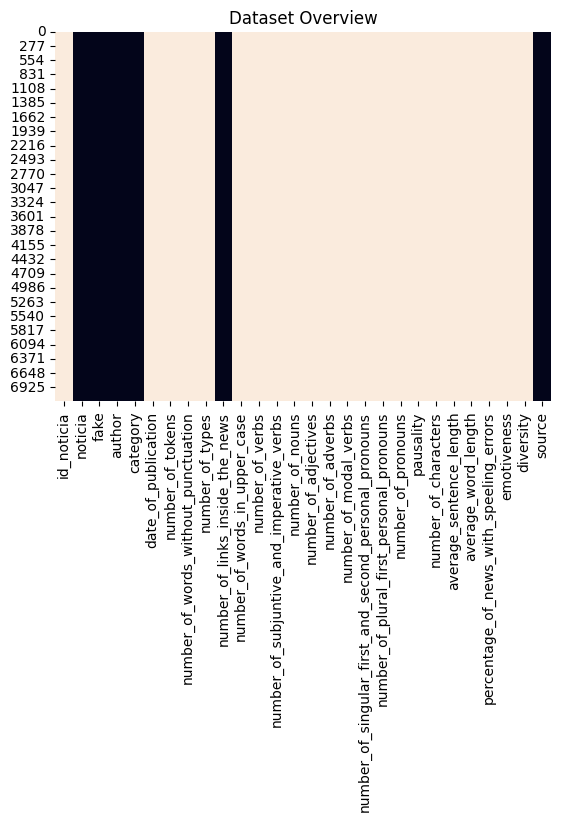

 Categorical   Numeric   NaN 


In [33]:
dic_cols = {col:utils_recognize_type(base, col, max_cat=20) for col in base.columns}
heatmap = base.isnull()
for k,v in dic_cols.items():
    if v == "num":
        heatmap[k] = heatmap[k].apply(lambda x: 0.5 if x is False else 1)
    else:
        heatmap[k] = heatmap[k].apply(lambda x: 0 if x is False else 1)
sns.heatmap(heatmap, cbar=False).set_title('Dataset Overview')
plt.show()
print("\033[1;37;40m Categorical ", "\033[1;30;41m Numeric ", "\033[1;30;47m NaN ")

In [34]:
base['number_of_links_inside_the_news'] = base['number_of_links_inside_the_news'].fillna(0)

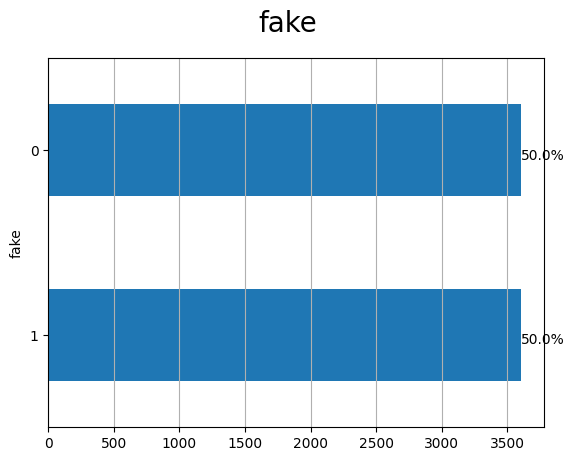

In [35]:
y = "fake"
ax = base[y].value_counts().sort_values().plot(kind="barh")
totals= []
for i in ax.patches:
    totals.append(i.get_width())
total = sum(totals)
for i in ax.patches:
     ax.text(i.get_width()+.3, i.get_y()+.20, 
     str(round((i.get_width()/total)*100, 2))+'%', 
     fontsize=10, color='black')
ax.grid(axis="x")
plt.suptitle(y, fontsize=20)
plt.show()

C:\Users\Caio\AppData\Local\Temp\ipykernel_6304\747134748.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(base[base[cat]==i][num], hist=False, label=i, ax=ax[0])
C:\Users\Caio\AppData\Local\Temp\ipykernel_6304\747134748.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(

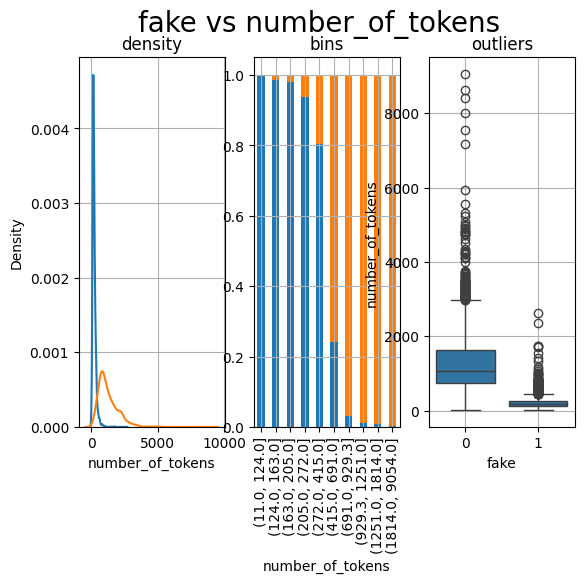

In [36]:
cat, num = "fake", "number_of_tokens"
fig, ax = plt.subplots(nrows=1, ncols=3,  sharex=False, sharey=False)

# CORREÇÃO 1: Trocando 'x' e 'y' por 'cat' e 'num' (usando f-strings para facilitar)
fig.suptitle(f"{cat} vs {num}", fontsize=20)

### distribution
ax[0].title.set_text('density')
for i in base[cat].unique():
    # Aviso: sns.distplot está obsoleto nas versões mais recentes do seaborn, 
    # se der erro no futuro, troque por sns.kdeplot(...) ou sns.histplot(..., kde=True)
    sns.distplot(base[base[cat]==i][num], hist=False, label=i, ax=ax[0])
ax[0].grid(True)

### stacked
ax[1].title.set_text('bins')
breaks = np.quantile(base[num], q=np.linspace(0,1,11))
tmp = base.groupby([cat, pd.cut(base[num], breaks, duplicates='drop')]).size().unstack().T
tmp = tmp[base[cat].unique()]
tmp["tot"] = tmp.sum(axis=1)
for col in tmp.drop("tot", axis=1).columns:
    tmp[col] = tmp[col] / tmp["tot"]
tmp.drop("tot", axis=1).plot(kind='bar', stacked=True, ax=ax[1], legend=False, grid=True)

### boxplot
ax[2].title.set_text('outliers')
# CORREÇÃO 2: Substituindo sns.catplot por sns.boxplot
sns.boxplot(x=cat, y=num, data=base, ax=ax[2]) 
ax[2].grid(True)

plt.show()

### Testes de hipótese

In [37]:
base = base.set_index(['id_noticia','noticia'])
base['fake'] = base['fake'].astype(int)

Para as variaveis categoricas

In [38]:
from scipy.stats import chi2_contingency, fisher_exact, pointbiserialr,ttest_ind
for i in ['category','author','source']:
    # Create a contingency table
    contingency_table = pd.crosstab(base['fake'], base[i])
    
    # Perform Chi-square test of independence
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print("p-value:", p_value)
    if p_value<.05:
        print(f'A variável {i} é correlacionada com a veracidade da informação e será mantida')
    else:
        print(f'A variável {i} não é correlacionada com a veracidade da informação e será descartada')
        base= base.drop('category',axis=1)

p-value: 1.0
A variável category não é correlacionada com a veracidade da informação e será descartada
p-value: 0.0
A variável author é correlacionada com a veracidade da informação e será mantida
p-value: 0.0
A variável source é correlacionada com a veracidade da informação e será mantida


Para as contínuas

In [39]:
for i in base.columns[1:]:
    if i!='category' and i.startswith('source')==False:
        # Separate the continuous variable by the fake groups
        group_0 = base[base['fake'] == 0][i]
        group_1 = base[base['fake'] == 1][i]
        
        # Perform Point-Biserial correlation
        correlation_coefficient, p_value_point_biserial = pointbiserialr(base['fake'], base[i])
        print("p-value Point BIserial Test:", p_value_point_biserial)
        
        # Perform independent samples t-test
        t_statistic, p_value_ttest = ttest_ind(group_0, group_1)
        
        print("p-value Ttest:", p_value_ttest)
        
        if p_value_ttest<.05 and p_value_point_biserial<.05:
            print(f'A variável {i} é correlacionada com a veracidade da informação e será mantida')
        else:
            print(f'A variável {i} não é correlacionada com a veracidade da informação e será descartada')
            base= base.drop(i,axis=1)

p-value Point BIserial Test: 0.0
p-value Ttest: 0.0
A variável author é correlacionada com a veracidade da informação e será mantida
p-value Point BIserial Test: 0.9999993945052402
p-value Ttest: 0.9999993945037162
A variável date_of_publication não é correlacionada com a veracidade da informação e será descartada
p-value Point BIserial Test: 0.0
p-value Ttest: 0.0
A variável number_of_tokens é correlacionada com a veracidade da informação e será mantida
p-value Point BIserial Test: 0.0
p-value Ttest: 0.0
A variável number_of_words_without_punctuation é correlacionada com a veracidade da informação e será mantida
p-value Point BIserial Test: 0.0
p-value Ttest: 0.0
A variável number_of_types é correlacionada com a veracidade da informação e será mantida
p-value Point BIserial Test: 9.251878773834741e-21
p-value Ttest: 9.25187877383543e-21
A variável number_of_links_inside_the_news é correlacionada com a veracidade da informação e será mantida
p-value Point BIserial Test: 2.3262710697111

c:\Users\Caio\Documents\Mestrado\PLN\projeto-pln-seminario-2\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


p-value Point BIserial Test: 1.0062000690159779e-13
p-value Ttest: 1.0062000690176523e-13
A variável average_word_length é correlacionada com a veracidade da informação e será mantida
p-value Point BIserial Test: 9.379757723830541e-214
p-value Ttest: 9.379757723827464e-214
A variável percentage_of_news_with_speeling_errors é correlacionada com a veracidade da informação e será mantida
p-value Point BIserial Test: 0.022850471814337983
p-value Ttest: 0.022850471814336915
A variável emotiveness é correlacionada com a veracidade da informação e será mantida
p-value Point BIserial Test: 0.0
p-value Ttest: 0.0
A variável diversity é correlacionada com a veracidade da informação e será mantida


Text(0.5, 1.0, 'pearson correlation')

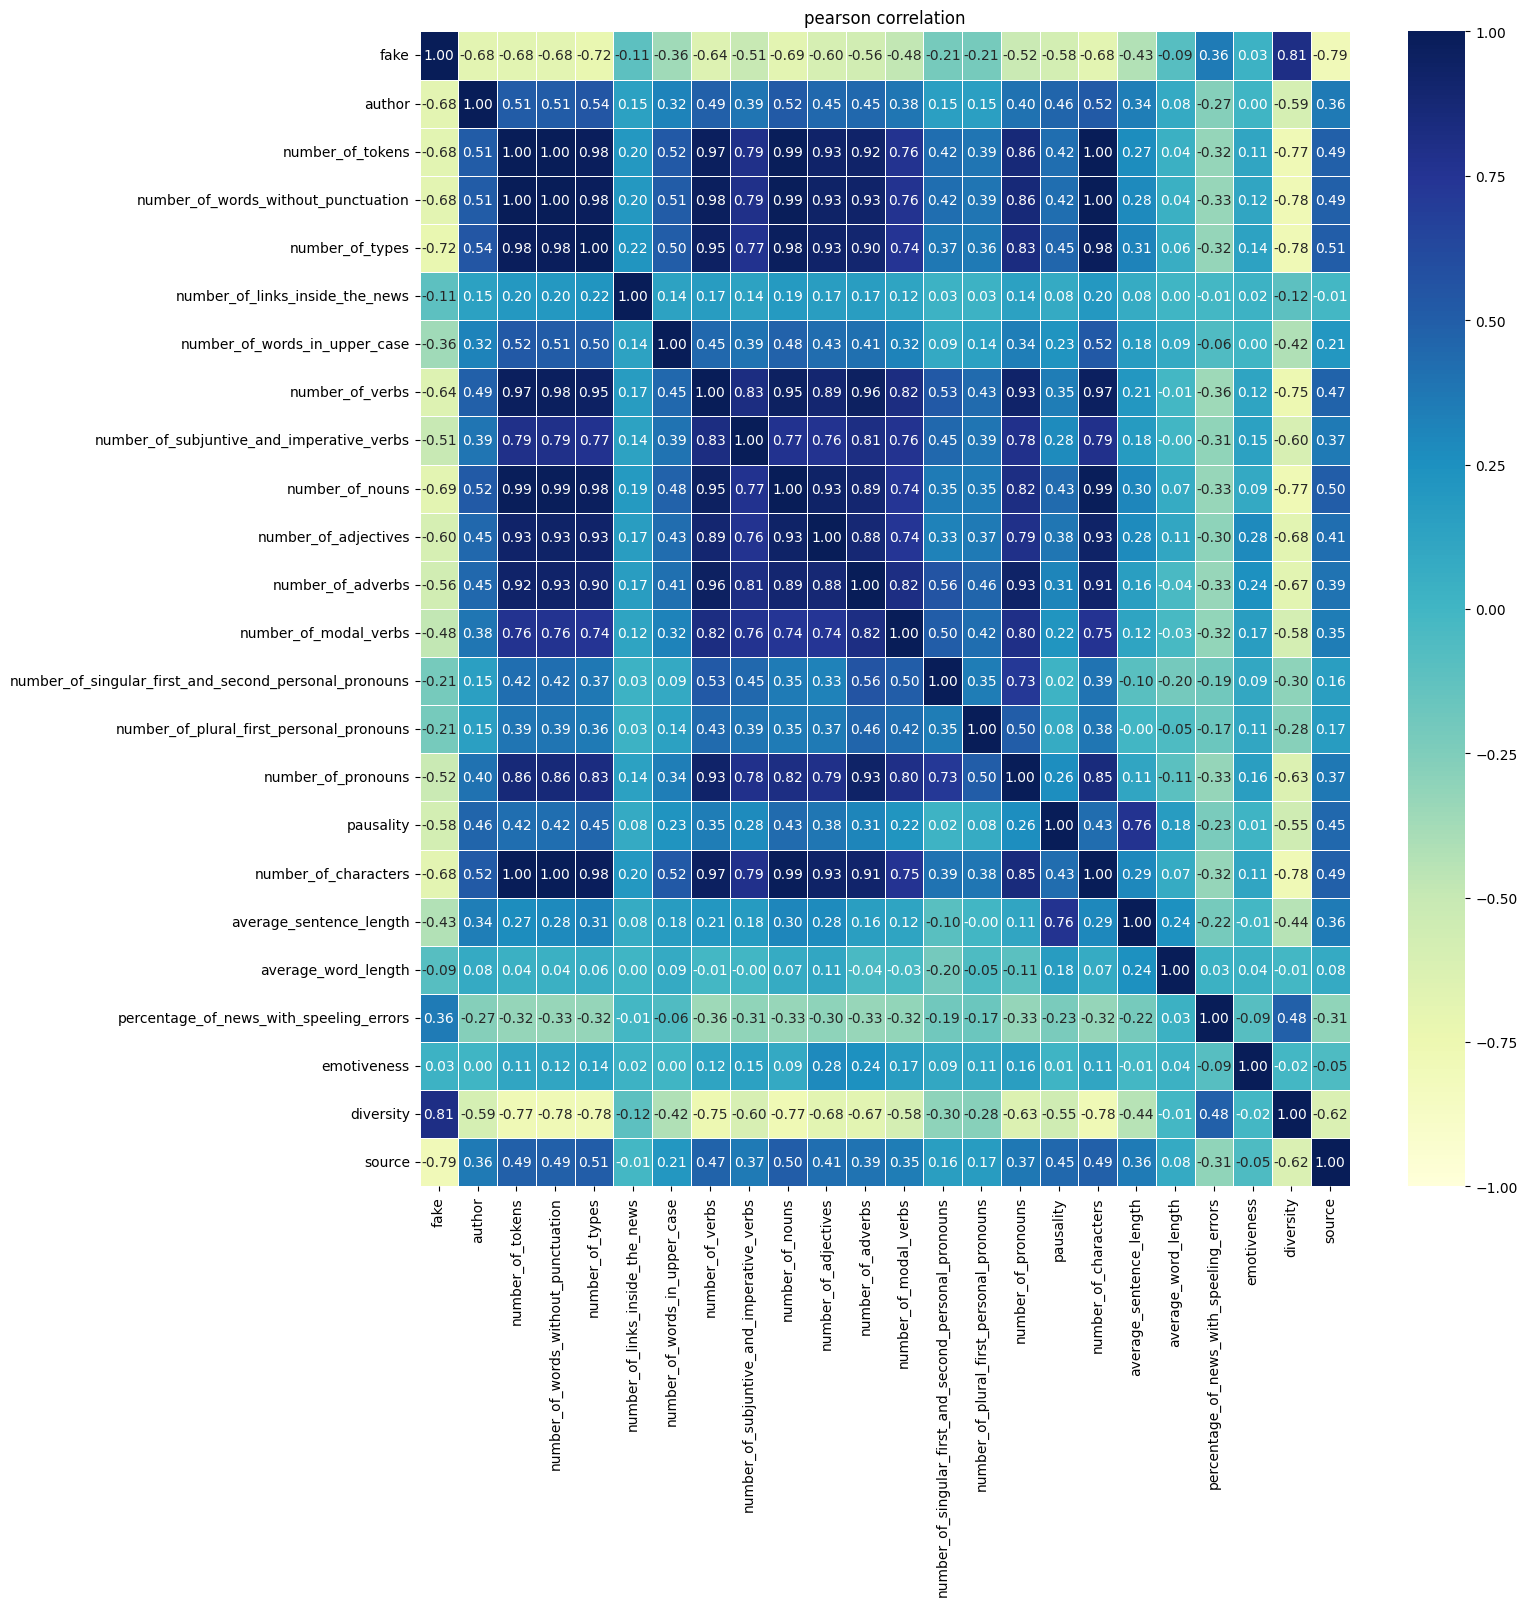

In [40]:
plt.figure(figsize=(15,15))
corr_matrix = base.copy()
for col in corr_matrix.columns:
    if corr_matrix[col].dtype == "O":
         corr_matrix[col] = corr_matrix[col].factorize(sort=True)[0]
corr_matrix = corr_matrix.corr(method="pearson")
sns.heatmap(corr_matrix, vmin=-1., vmax=1., annot=True, fmt='.2f', cmap="YlGnBu", cbar=True, linewidths=0.5)

plt.title("pearson correlation")

As features que restaram mesmo sendo redundantes demonstraram bastante importancia SHAP. Então quem vai ser excluido é:

In [41]:
# Ablação: descartamos 'source' sem criar dummies.
# Apesar de estatisticamente significativa (como mostrado acima),
# queremos avaliar o que acontece sem esse atalho de domínio.
del base['source']

## Separação do conjunto de teste e de treinamento

In [42]:
## split data
df_train, df_test = model_selection.train_test_split(base, 
                      test_size=0.3,random_state=roll_dice)
## print info
print("X_train shape:", df_train.drop("fake",axis=1).shape, "| X_test shape:", df_test.drop("fake",axis=1).shape)
print("y_train mean:", round(np.mean(df_train["fake"]),2), "| y_test mean:", round(np.mean(df_test["fake"]),2))
print(df_train.shape[1], "features:", df_train.drop("fake",axis=1).columns.to_list())

X_train shape: (5040, 22) | X_test shape: (2160, 22)
y_train mean: 0.5 | y_test mean: 0.5
23 features: ['author', 'number_of_tokens', 'number_of_words_without_punctuation', 'number_of_types', 'number_of_links_inside_the_news', 'number_of_words_in_upper_case', 'number_of_verbs', 'number_of_subjuntive_and_imperative_verbs', 'number_of_nouns', 'number_of_adjectives', 'number_of_adverbs', 'number_of_modal_verbs', 'number_of_singular_first_and_second_personal_pronouns', 'number_of_plural_first_personal_pronouns', 'number_of_pronouns', 'pausality', 'number_of_characters', 'average_sentence_length', 'average_word_length', 'percentage_of_news_with_speeling_errors', 'emotiveness', 'diversity']


### Escala a base de dados

In [43]:
train_scaler = preprocessing.MinMaxScaler(feature_range=(0,1))
X = train_scaler.fit_transform(df_train.drop('fake',axis=1))
df_train_scaled= pd.DataFrame(X, columns=df_train.drop('fake',axis=1).columns, index=df_train.index)
df_train_scaled["fake"] = df_train["fake"]
df_train_scaled["fake"] = df_train_scaled["fake"].astype('int')

In [44]:
scaler = preprocessing.MinMaxScaler(feature_range=(0,1))
X = scaler.fit_transform(df_test.drop('fake',axis=1))
df_test_scaled= pd.DataFrame(X, columns=df_test.drop('fake',axis=1).columns, index=df_test.index)
df_test_scaled["fake"] = df_test["fake"]
df_test_scaled["fake"] = df_test_scaled["fake"].astype('int')

In [45]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
# Import other classifiers you want to test

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

# Create a dictionary to store the classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=roll_dice),
    'Decision Tree': DecisionTreeClassifier(random_state=roll_dice),
    'Random Forest': RandomForestClassifier(random_state=roll_dice),
    'Gradient Boosting': GradientBoostingClassifier(random_state=roll_dice),
    'AdaBoost': AdaBoostClassifier(random_state=roll_dice),
    'Support Vector Machine': SVC(probability=True,random_state=roll_dice),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Neural Network': MLPClassifier(random_state=roll_dice, max_iter=600),
    'Naive Bayes': GaussianNB()
}

In [46]:
X_train = df_train_scaled[[col for col in df_train_scaled.columns if col!='fake']].fillna(0).values
y_train = df_train['fake'].values.astype('int')
X_test = df_test_scaled[[col for col in df_test_scaled.columns if col!='fake']].fillna(0).values
y_test = df_test['fake'].values.astype('int')

In [47]:
def get_cross_validation_results(Xtrain, ytrain):
    results = {}
    kfold = KFold(n_splits=5, shuffle=True, random_state=roll_dice)  # 5-fold cross-validation
    
    for name, clf in classifiers.items():
        scores = cross_val_score(clf, Xtrain, ytrain, cv=kfold, scoring='accuracy')
        results[name] = scores.mean()
    return results

In [48]:
def get_best_model(Xtrain,ytrain):
    results = get_cross_validation_results(Xtrain, ytrain)
    results = pd.DataFrame(results.items(),columns=['model','accuracy']).set_index('model')
    best_model_name=results.index[results['accuracy'].argmax()]
    best_model = classifiers[best_model_name]
    best_model.fit(Xtrain, ytrain)
    return results, best_model_name,best_model

### Observação: Só dá certo se o modelo não for o NB

In [49]:
def get_feature_importances(df_train):
    X_train= df_train[[col for col in df_train.columns if col!='fake']].fillna(0).values
    y_train = df_train['fake'].values.astype('int')
    results,best_model_name,best_model = get_best_model(X_train,y_train)
    best_model.fit(X_train,y_train)
    if best_model_name!='Support Vector Machine':
        if best_model_name=="Logistic Regression":
            importancias = pd.DataFrame(zip(df_train[[col for col in df_train.columns if col!='fake']].columns,best_model.coef_[0]), columns=['variavel','importancia'])
        elif  best_model_name== "Neural Network":
            importancias = pd.DataFrame(zip(df_train[[col for col in df_train.columns if col!='fake']].columns,best_model.coefs_[0]), columns=['variavel','importancia'])
        
        else:
             importancias = pd.DataFrame(zip(df_train[[col for col in df_train.columns if col!='fake']].columns,best_model.feature_importances_), columns=['variavel','importancia'])
                
        importancias['importancia_abs']= importancias['importancia'].apply(lambda i:np.abs(i)).all().sort_values(ascending=False)
        importancias ['expressividade absoluta']=importancias['importancia_abs']/importancias['importancia_abs'].sum()
        importancias ['expressividade para a classe']=importancias['importancia'].apply(calculate_share(importancias,'importancia'))
        importancias['classe'] = importancias['importancia'].apply(lambda i:True if i<0 else False)   
    
    else:
        importancias = "Não existe um método direto de importancia de features para Maquinas de Vetor de Suporte. Tente usar a análise SHAP"

    
    return best_model_name, best_model,importancias

In [50]:
def calculate_share(df, column_name):
    column = df[column_name]
    positive_sum = column[column > 0].sum()
    negative_sum = column[column < 0].sum()

    def calculate_share_helper(value):
        if value > 0:
            return value / positive_sum if positive_sum != 0 else 0
        elif value < 0:
            return value / negative_sum if negative_sum != 0 else 0
        else:
            return 0

    return calculate_share_helper

In [51]:
def get_test_results(model_name,model,X_train,X_test, y_train,y_test,iteration_name="All variables"): 
    #X_train= df_train[[col for col in df_train.columns if col!='fake']].fillna(0).values
    #y_train = df_train['fake'].values.astype('int')
    #X_test= df_test[[col for col in df_test.columns if col!='fake']].fillna(0).values
    #y_test = df_test['fake'].values.astype('int')
    ## train
    model.fit(X_train, y_train)
    ## test
    y_pred = model.predict(X_test)
    
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix
    
    # Assuming you have the best model stored as 'best_model' and the test dataset as 'Xtest' and 'ytest'
    
    
    print(f"Modelo: {model_name}")
    print(f"Modelo: {model}")
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy}")
    
    # Calculate F1 score
    f1 = f1_score(y_test, y_pred)
    print(f"F1 Score: {f1}")
    
    # Calculate recall
    recall = recall_score(y_test, y_pred)
    print(f"Recall: {recall}")
    
    # Calculate precision
    precision = precision_score(y_test, y_pred)
    print(f"Precision: {precision}")
    
    # Create confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {iteration_name}")
    plt.savefig(f'figures/figures_ablacao/Confusion Matrix - {iteration_name}.pdf')
    plt.show()
    

## Ablação

In [52]:
df_train_scaled_context = df_train_scaled[[col for col in df_train_scaled.columns if col.startswith('source') or col=='author' or col=='date_of_publication' or col=='fake']]
df_train_scaled_content = df_train_scaled[[col for col in df_train_scaled.columns if col not in df_train_scaled_context.columns or col=='fake']]
df_test_scaled_context = df_test_scaled[[col for col in df_test_scaled.columns if col.startswith('source') or col=='author' or col=='date_of_publication'or col=='fake']]
df_test_scaled_content = df_test_scaled[[col for col in df_test_scaled.columns if col not in df_test_scaled_context.columns or col=='fake']]

In [53]:
df_train_context = df_train_scaled[[col for col in df_train_scaled.columns if col.startswith('source') or col=='author' or col=='date_of_publication' or col=='fake']]
df_train_content = df_train_scaled[[col for col in df_train_scaled.columns if col not in df_train_context.columns or col=='fake']]
df_test_context = df_test_scaled[[col for col in df_test_scaled.columns if col.startswith('source') or col=='author' or col=='date_of_publication'or col=='fake']]
df_test_content = df_test_scaled[[col for col in df_test_scaled.columns if col not in df_test_context.columns or col=='fake']]

In [54]:
X = np.vstack((df_train[[col for col in df_train.columns if col!='fake']].fillna(0).values, df_test[[col for col in df_test.columns if col!='fake']].fillna(0).values ))
y = list(df_train_scaled_content['fake'].values.astype('int'))+list(df_test_scaled_content['fake'].values.astype('int'))

## Conteúdo

In [55]:
exclusao_redundantes= [
                        #'number_of_characters',
                        #'number_of_tokens',
                       #'number_of_subjuntive_and_imperative_verbs',  
                       #'number_of_modal_verbs',
                       'number_of_verbs',
                       "number_of_types",
                       "number_of_adjectives",
                       #"number_of_pronouns",
                       "number_of_adverbs",
                        "number_of_nouns",
                        #'number_of_words_without_punctuation' 
                        
]

In [56]:
X_train_content=df_train_scaled_content.reset_index()[[col for col in df_train_scaled_content.columns if col!='fake' and col not in exclusao_redundantes ]].fillna(0)
y_train_content=df_train_scaled_content.reset_index()['fake'].fillna(0).astype('int')
X_test_content=df_test_scaled_content.reset_index()[[col for col in df_test_scaled_content.columns if col!='fake' and col not in exclusao_redundantes]].fillna(0)
y_test_content=df_test_scaled_content.reset_index()['fake'].fillna(0).astype('int')
X_content = pd.concat([X_train_content,X_test_content],axis=0)
y_content = pd.concat([y_train_content,y_test_content],axis=0)

In [57]:
content_model_results,content_model_name,content_model= get_best_model(X_train_content,y_train_content)

Modelo: Random Forest
Modelo: RandomForestClassifier(random_state=0)
Accuracy: 0.9518518518518518
F1 Score: 0.9522497704315886
Recall: 0.9557603686635945
Precision: 0.9487648673376029


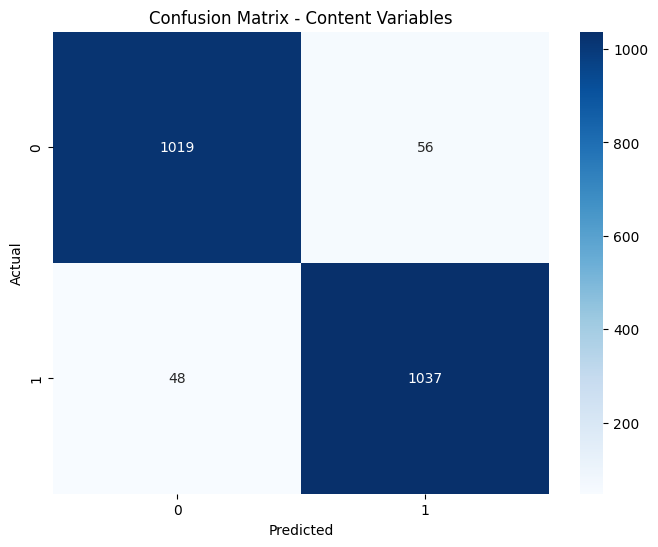

In [58]:
get_test_results(content_model_name,content_model,X_train_content,X_test_content,y_train_content,y_test_content,"Content Variables")

## Contexto

In [59]:
X_train_context=df_train_scaled_context.reset_index()[[col for col in df_train_scaled_context.columns if col!='fake']].fillna(0)
y_train_context=df_train_scaled_context.reset_index()['fake'].fillna(0).astype('int')
X_test_context=df_test_scaled_context.reset_index()[[col for col in df_test_scaled_context.columns if col!='fake']].fillna(0)
y_test_context=df_test_scaled_context.reset_index()['fake'].fillna(0).astype('int')
X_context = pd.concat([X_train_context,X_test_context],axis=0)
y_context = pd.concat([y_train_context,y_test_context],axis=0)

In [60]:
context_model_results,context_model_name,context_model= get_best_model(X_train_context,y_train_context)

Modelo: Logistic Regression
Modelo: LogisticRegression(random_state=0)
Accuracy: 0.8162037037037037
F1 Score: 0.8425228084093613
Recall: 0.9788018433179724
Precision: 0.7395543175487466


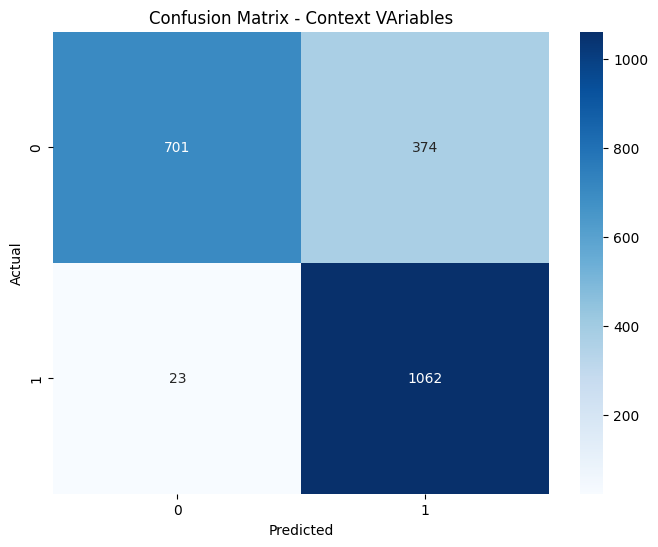

In [61]:
get_test_results(context_model_name,context_model,X_train_context,X_test_context,y_train_context,y_test_context,"Context VAriables")

## Conteúdo + Contexto

In [62]:
general_model_results,general_model_name,general_model= get_best_model(X_train,y_train)

Modelo: Random Forest
Modelo: RandomForestClassifier(random_state=0)
Accuracy: 0.961574074074074
F1 Score: 0.9612692487167522
Recall: 0.9493087557603687
Precision: 0.9735349716446124


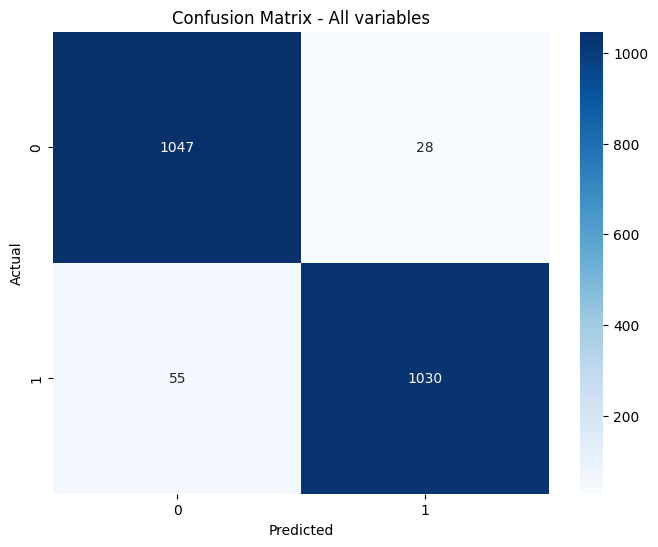

In [63]:
get_test_results(general_model_name,general_model,X_train,X_test,y_train,y_test)

## Validação Externa com o FakeRecogna

Os três modelos treinados acima (Conteúdo, Contexto, Conteúdo+Contexto) foram avaliados até aqui só dentro do próprio Fake.BR Corpus. Esta seção tem o objetivo de entender o quanto essa performance se sustenta fora do corpus de treino, usando o [FakeRecogna](https://github.com/Gabriel-Lino-Garcia/FakeRecogna) (11.902 notícias, balanceadas, categorias Brasil/Entretenimento/Saúde/Política/Ciência/Mundo).

Pontos importantes:
- **Polaridade invertida**: no FakeRecogna, `Class`: 0=fake, 1=real. Aqui, `fake`: 1=fake, 0=real. Será feita uma conversão `fake = 1 - Class`.
- **Nenhum reajuste é feito no FakeRecogna**: o scaler usado é o mesmo já fitado no treino do Fake.BR (`train_scaler`, sem refit), e qualquer valor faltante de data é preenchido com a média já computada no treino do Fake.BR, com o objetivo de reduzir variação na generalização.
- **Colunas de contexto que não existem no FakeRecogna**: `source_*` e `category` caem em 0 via `reindex`, por consequência da transferência de corpora.


In [64]:
import requests


### Download do FakeRecogna

Baixa o arquivo `FakeRecogna_no_removal_words.xlsx` direto do GitHub, caso ainda não exista localmente.


In [65]:
FAKERECOGNA_URL = "https://raw.githubusercontent.com/Gabriel-Lino-Garcia/FakeRecogna/master/dataset/FakeRecogna_no_removal_words.xlsx"
FAKERECOGNA_PATH = "FakeRecogna_no_removal_words.xlsx"

if not os.path.exists(FAKERECOGNA_PATH):
    resposta = requests.get(FAKERECOGNA_URL, timeout=60)
    resposta.raise_for_status()
    with open(FAKERECOGNA_PATH, "wb") as f:
        f.write(resposta.content)
    print(f"Baixado: {len(resposta.content)/1e6:.1f} MB")


In [66]:
df_fr = pd.read_excel(FAKERECOGNA_PATH)
print(df_fr.shape)
print(df_fr.columns.tolist())
df_fr['Classe'].value_counts()


(11902, 8)
['Titulo', 'Subtitulo', 'Noticia', 'Categoria', 'Data', 'Autor', 'URL', 'Classe']


Classe
0    5951
1    5951
Name: count, dtype: int64

Exibição do formato de data do FakeRecogna:

In [67]:
df_fr['Data'].head(10)


0                                         17/08/2021
1                                  23/10/2020 10h02 
2                                  27/10/2020 04h00 
3                                  10/02/2021 23h56 
4                                11/08/2020 às 20:45
5                                  24/05/2020 04h00 
6                                 2/06/2021 às 22:16
7                                  14/04/2020 13h02 
8    12/01/2021 10h38Atualizada em 12/01/2021 10h49 
9                                         13/05/2019
Name: Data, dtype: object

In [68]:
df_fr = df_fr.dropna(subset=['Noticia']).copy()
df_fr['noticia'] = df_fr['Noticia'].astype(str).str.strip()
df_fr['fake'] = 1 - df_fr['Classe'].astype(int)
df_fr['link'] = df_fr['URL']
df_fr = df_fr.reset_index(drop=True)
df_fr.shape


(11902, 11)

### Extração das 21 features linguísticas via spaCy

Reusamos `nlp` e a função `extrai_features_morfossintaticas(doc)` definidas anteriormente neste notebook. Como o fakeRecogna não possui as features, precisamos gerá-las pelo mesmo método que fizemos anteriormente.

In [69]:
inicio = time.time()
docs_fr = nlp.pipe(df_fr['noticia'].tolist(), batch_size=50)
linhas_features_fr = [extrai_features_morfossintaticas(doc) for doc in docs_fr]
df_fr_morfo = pd.DataFrame(linhas_features_fr, index=df_fr.index)
print(f"Extração concluída em {time.time()-inicio:.1f}s para {len(df_fr_morfo)} notícias")
df_fr_morfo.head()


Extração concluída em 140.8s para 11902 notícias


,number_of_tokens,number_of_words_without_punctuation,number_of_types,number_of_links_inside_the_news,number_of_words_in_upper_case,number_of_verbs,number_of_subjuntive_and_imperative_verbs,number_of_nouns,number_of_adjectives,number_of_adverbs,...,number_of_singular_first_and_second_personal_pronouns,number_of_plural_first_personal_pronouns,number_of_pronouns,pausality,number_of_characters,average_sentence_length,average_word_length,percentage_of_news_with_speeling_errors,emotiveness,diversity
0,34,34,19,0,0,15,0,10,4,0,...,0,0,0,0.0,228,34.0,5.735294,8.823529,0.160000,0.558824
1,50,45,32,0,0,18,1,16,4,0,...,0,0,0,0.0,355,22.5,6.444444,11.111111,0.117647,0.711111
2,92,87,59,0,0,30,0,19,12,0,...,0,0,0,0.0,625,43.5,5.689655,16.091954,0.244898,0.678161
3,53,52,39,0,0,16,0,13,3,2,...,0,0,1,0.0,337,52.0,5.442308,11.538462,0.172414,0.750000
4,115,102,64,0,0,31,3,31,12,4,...,0,0,1,0.0,779,34.0,6.235294,14.705882,0.258065,0.627451


### Features de contexto


In [70]:
df_fr['source'] = df_fr['link'].str.extract(r'(https?://(?:www\.)?([^/]+))')[1]
df_fr['source'] = df_fr['source'].apply(lambda i: "estadao.com.br" if "estadao" in i else "folha.com.br" if "folha" in i and "uol" in i else i)
df_fr['source'].value_counts()


source
noticias.uol.com.br          4025
boatos.org                   2484
g1.globo.com                 2284
e-farsas.com                  804
checamos.afp.com              503
uol.com.br                    488
projetocomprova.com.br        388
economia.uol.com.br           312
extra.globo.com               223
gov.br                        215
entretenimento.uol.com.br      65
tvefamosos.uol.com.br          64
educacao.uol.com.br            43
tab.uol.com.br                  4
Name: count, dtype: int64

In [71]:
df_fr['author'] = df_fr['Autor'].apply(is_real_author)
print(f"FakeRecogna — author=1: {df_fr['author'].sum()} / {len(df_fr)} ({100*df_fr['author'].mean():.1f}%)")
df_fr['Autor'].dropna().head(20).tolist()


FakeRecogna — author=1: 9694 / 11902 (81.4%)


['\nEdgard Matsuki ',
 ' Por G1 ',
 'Carlos Madeiro',
 '10/02/2021 23h56 ',
 'AFP Austrália',
 'Elisa Soupin',
 'AFP Brasil',
 '14/04/2020 13h02 ',
 '12/01/2021 10h38Atualizada em 12/01/2021 10h49 ',
 'marco faustino',
 '26/03/2021 11h21 ',
 '04/05/2020 12h50 ',
 'gilmar lopes',
 'Comprova',
 'Comprova',
 ' Por Roney Domingos, Gabriel Morais, Vinícius Cassela e Marcelo Gomes, G1, O Globo, TV Globo e GloboNews ',
 'Wanderley Preite Sobrinho',
 ' Por Felipe Grandin, G1 ',
 ' Por G1, O Globo, Extra, TV Globo, CBN, Valor e GloboNews ',
 ' Por Roney Domingos, G1 São Paulo ']

In [72]:
if 'date_of_publication' in base.columns:
    date_of_publication_train_mean = base['date_of_publication'].mean()
else:
    date_of_publication_train_mean = 0

data_extraida = df_fr['Data'].astype(str).str.extract(r'(\d{1,2}/\d{1,2}/\d{4})')[0]
df_fr['date_of_publication'] = pd.to_datetime(data_extraida, errors='coerce', dayfirst=True)
print('Datas nao reconhecidas:', df_fr['date_of_publication'].isna().sum(), 'de', len(df_fr))
df_fr['date_of_publication'] = df_fr['date_of_publication'].apply(
    lambda i: int(i.timestamp()) if pd.notna(i) else int(date_of_publication_train_mean)
)


Datas nao reconhecidas: 963 de 11902


### Alinhamento de colunas e escala

Para adequar as entradas do fakeRecogna ao que foi treinado, fazemos o fit do `train_scaler` uma única vez sobre o `df_train`, antes do split das colunas, que só acontece na ablação. Por isso aqui também escalamos uma vez só, com a lista completa de colunas de treino, e só depois cortamos em Conteúdo/Contexto/Geral,seguindo o que o pipeline original faz.


In [73]:
general_train_columns = [col for col in df_train_scaled.columns if col != 'fake']
content_train_columns = X_train_content.columns.tolist()
context_train_columns = X_train_context.columns.tolist()

len(general_train_columns), len(content_train_columns), len(context_train_columns)


(22, 16, 1)

In [74]:
# Sem source dummies: apenas features linguísticas + author + date_of_publication
df_fr_raw = pd.concat([df_fr_morfo, df_fr[['author', 'date_of_publication']]], axis=1)
df_fr_aligned = df_fr_raw.reindex(columns=general_train_columns, fill_value=0)
df_fr_aligned.shape

(11902, 22)

In [75]:
X_fr_scaled = pd.DataFrame(
    train_scaler.transform(df_fr_aligned),
    columns=general_train_columns,
    index=df_fr.index,
)

X_fr_content = X_fr_scaled[content_train_columns]
X_fr_context = X_fr_scaled[context_train_columns]
X_fr_general = X_fr_scaled[general_train_columns].values

y_fr = df_fr['fake'].astype(int)


### Resultados da validação externa

Reusa `get_test_results` para refittar cada modelo nos dados de treino do Fake.BR e testa contra o FakeRecogna alinhado/escalado acima.


Modelo: Random Forest
Modelo: RandomForestClassifier(random_state=0)
Accuracy: 0.5000840194925222
F1 Score: 0.6641074856046065
Recall: 0.9884053100319274
Precision: 0.5000425061633937


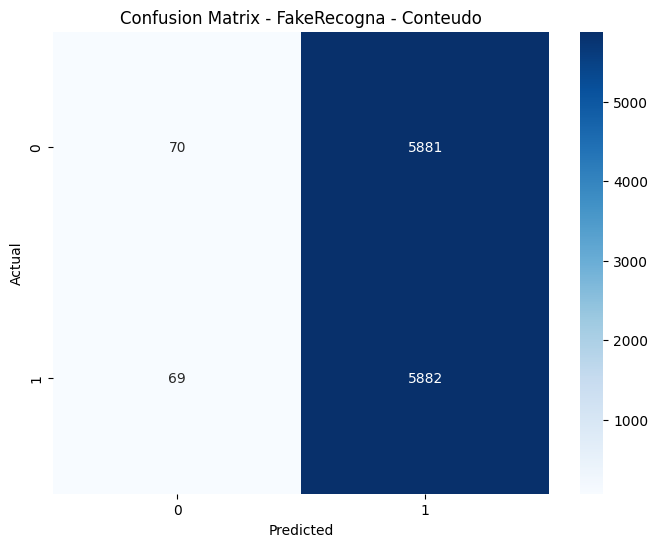

In [76]:
get_test_results(content_model_name, content_model, X_train_content, X_fr_content, y_train_content, y_fr, "FakeRecogna - Conteudo")


Modelo: Logistic Regression
Modelo: LogisticRegression(random_state=0)
Accuracy: 0.5369685767097967
F1 Score: 0.324549577154063
Recall: 0.22248361619895815
Precision: 0.5996376811594203


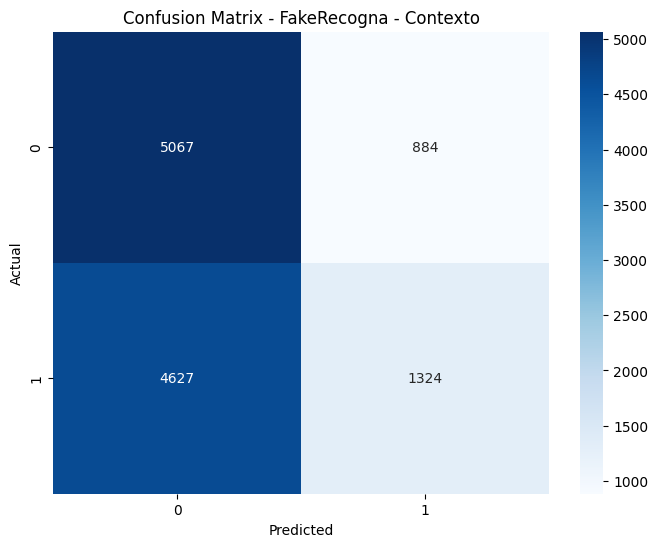

In [77]:
get_test_results(context_model_name, context_model, X_train_context, X_fr_context, y_train_context, y_fr, "FakeRecogna - Contexto")


Modelo: Random Forest
Modelo: RandomForestClassifier(random_state=0)
Accuracy: 0.453117123172576
F1 Score: 0.6032790881940635
Recall: 0.8316249369853806
Precision: 0.4733167559296098


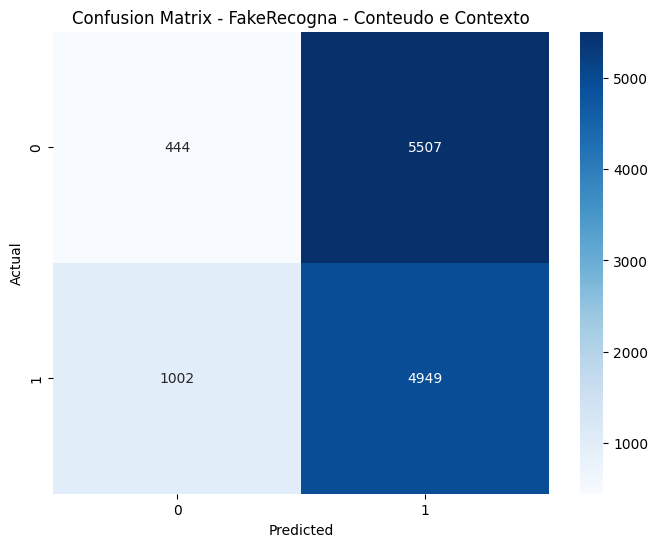

In [78]:
get_test_results(general_model_name, general_model, X_train, X_fr_general, y_train, y_fr, "FakeRecogna - Conteudo e Contexto")


### Explicabilidade no FakeRecogna

As células acima mostram o desempenho dos modelos no FakeRecogna. Esta seção usa SHAP para entender quais features guiam essas predições.

Para o **Contexto**, o interesse é ver se o modelo aprendeu a identificar domínios confiáveis (source dummies) ou padrões mais gerais como a presença de autor. Uma célula verifica quais source dummies estão ativas no FakeRecogna antes dos gráficos.

Para o **Conteúdo**, o SHAP mostra quais das 21 features linguísticas o modelo usa ao classificar notícias externas.

#### SHAP - Conteúdo (features linguísticas)

Três tipos de gráfico, espelhando o notebook base:
- **Beeswarm summary**: importância global com direção e distribuição de efeitos sobre todos os artigos do FakeRecogna.
- **Dependence plots** das 2 features com maior |SHAP| médio: mostra como o valor da feature se relaciona com o quanto ela move a predição.
- **Force plots** da predição correta mais confiante e da predição errada mais confiante: explicação individual, mostra quais features empurraram a predição para cima/baixo da base rate naquele artigo específico.


In [79]:
import os
os.makedirs('figures/figures_ablacao', exist_ok=True)

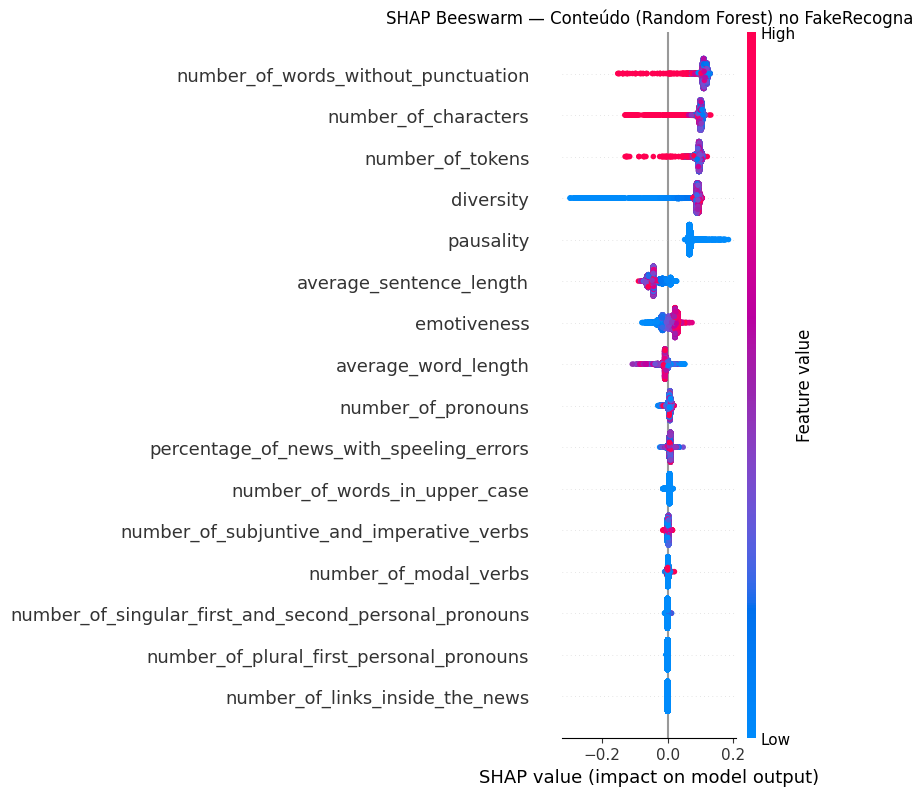

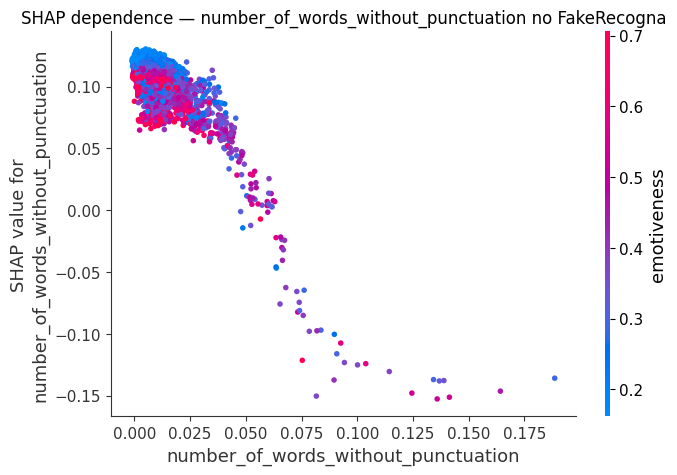

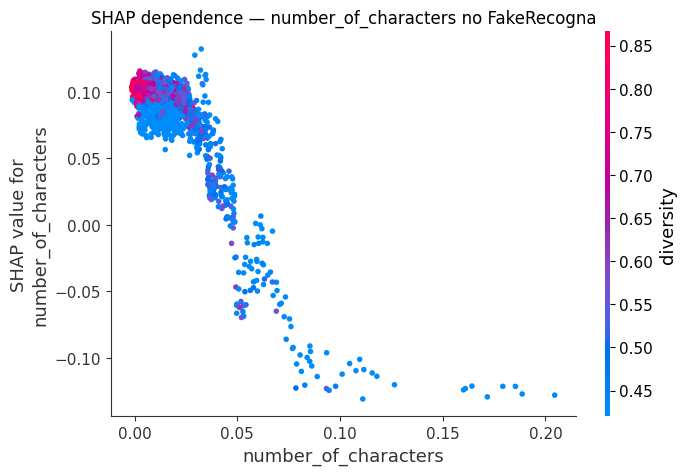

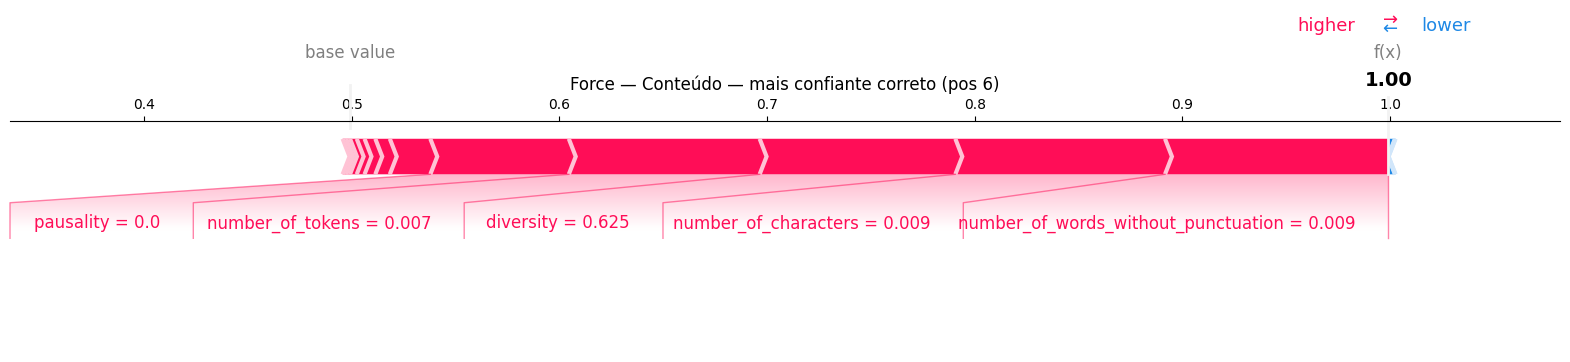

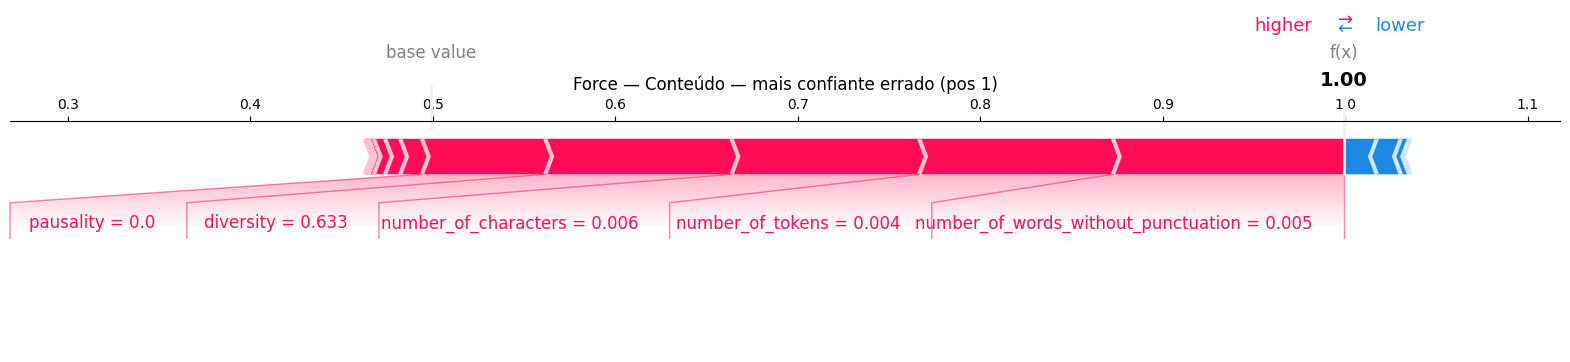

In [80]:
import shap
import numpy as np

def _shap_values_class1(model, X_train, X_test):
    """SHAP values para classe 1 (fake): Tree → Linear → Kernel em cascata."""
    if hasattr(model, 'estimators_'):
        exp = shap.TreeExplainer(model)
        sv = exp.shap_values(X_test)
    else:
        try:
            exp = shap.LinearExplainer(model, X_train)
            sv = exp.shap_values(X_test)
        except (ValueError, AttributeError, TypeError):
            if hasattr(model, 'predict_proba'):
                fn = model.predict_proba
            else:
                def fn(X):
                    d = model.decision_function(X)
                    p = 1.0 / (1.0 + np.exp(-d))
                    return np.column_stack([1 - p, p])
            bg = shap.sample(X_train, min(100, len(X_train)))
            exp = shap.KernelExplainer(fn, bg)
            sv = exp.shap_values(X_test)
    if isinstance(sv, list):
        sv = sv[1]
    if sv.ndim == 3:
        sv = sv[:, :, 1]
    return sv

def _proba_class1(model, X):
    """Probabilidade da classe 1 para qualquer modelo sklearn."""
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    d = model.decision_function(X)
    return 1.0 / (1.0 + np.exp(-d))

# Garante que o modelo está fitado com as 16 features de Conteúdo
# (classifiers{} é compartilhado — o mesmo objeto pode ter sido refitado
# com features do cenário Geral pelo get_test_results anterior)
content_model.fit(X_train_content, y_train_content)
sv_c = _shap_values_class1(content_model, X_train_content, X_fr_content)

# Beeswarm summary
plt.figure(figsize=(10, 5))
shap.summary_plot(sv_c, X_fr_content, show=False)
plt.title(f'SHAP Beeswarm — Conteúdo ({content_model_name}) no FakeRecogna')
plt.savefig('figures/figures_ablacao/shap_content_beeswarm_fakerecogna.pdf', bbox_inches='tight')
plt.show()

# Dependence plots das 2 features com maior |SHAP| médio
import pandas as pd
top2_c = pd.Series(np.abs(sv_c).mean(axis=0), index=X_fr_content.columns).nlargest(2).index
for feat in top2_c:
    shap.dependence_plot(feat, sv_c, X_fr_content, show=False)
    plt.title(f'SHAP dependence — {feat} no FakeRecogna')
    feat_safe = feat.replace('/', '_').replace(' ', '_')
    plt.savefig(f'figures/figures_ablacao/shap_dep_content_{feat_safe}_fakerecogna.pdf', bbox_inches='tight')
    plt.show()

# Force plots: mais confiante correto e mais confiante errado
proba_c  = _proba_class1(content_model, X_fr_content)
pred_c   = (proba_c >= 0.5).astype(int)
base_c   = _proba_class1(content_model, X_train_content).mean()
y_fr_arr = y_fr.values

corretos_c = np.where(pred_c == y_fr_arr)[0]
errados_c  = np.where(pred_c != y_fr_arr)[0]

for idx, rotulo in [
    (corretos_c[np.argmax(np.abs(proba_c[corretos_c] - 0.5))] if len(corretos_c) else None, 'correto'),
    (errados_c[np.argmax(np.abs(proba_c[errados_c] - 0.5))]   if len(errados_c)  else None, 'errado'),
]:
    if idx is None:
        continue
    shap.plots.force(
        base_value=base_c,
        shap_values=sv_c[idx],
        features=np.round(X_fr_content.iloc[idx].values, 3),
        feature_names=X_fr_content.columns.tolist(),
        matplotlib=True, show=False,
    )
    plt.title(f'Force — Conteúdo — mais confiante {rotulo} (pos {idx})')
    plt.savefig(f'figures/figures_ablacao/force_content_{rotulo}_fakerecogna.pdf', bbox_inches='tight')
    plt.show()


#### SHAP - Contexto

Três tipos de gráfico, espelhando o notebook base:
- **Beeswarm summary**: importância global com direção e distribuição de efeitos sobre todos os artigos do FakeRecogna.
- **Dependence plots** das 2 features com maior |SHAP| médio: mostra como o valor da feature se relaciona com o quanto ela move a predição.
- **Force plots** da predição correta mais confiante e da predição errada mais confiante: explicação individual, mostra quais features empurraram a predição para cima/baixo da base rate naquele artigo específico.

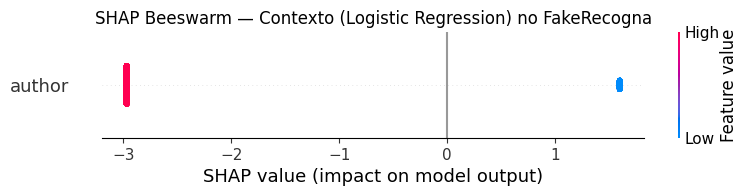

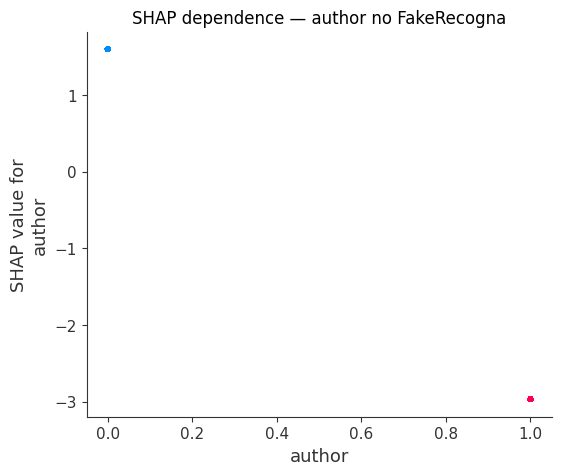

c:\Users\Caio\Documents\Mestrado\PLN\projeto-pln-seminario-2\.venv\Lib\site-packages\shap\plots\_force_matplotlib.py:107: RuntimeWarning: divide by zero encountered in scalar divide
  feature_contribution = np.abs(float(feature[0]) - pre_val) / np.abs(total_effect)


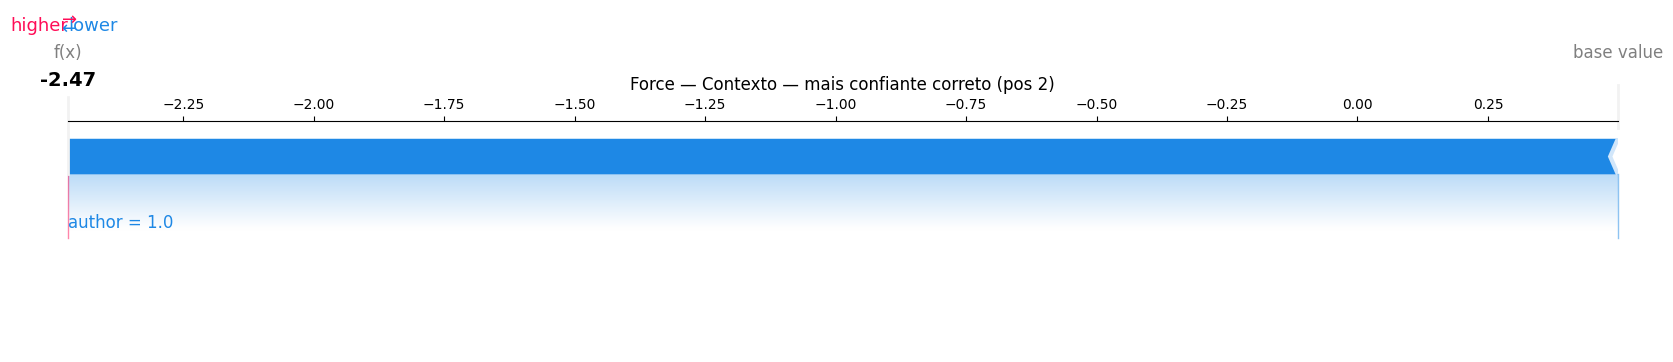

c:\Users\Caio\Documents\Mestrado\PLN\projeto-pln-seminario-2\.venv\Lib\site-packages\shap\plots\_force_matplotlib.py:107: RuntimeWarning: divide by zero encountered in scalar divide
  feature_contribution = np.abs(float(feature[0]) - pre_val) / np.abs(total_effect)


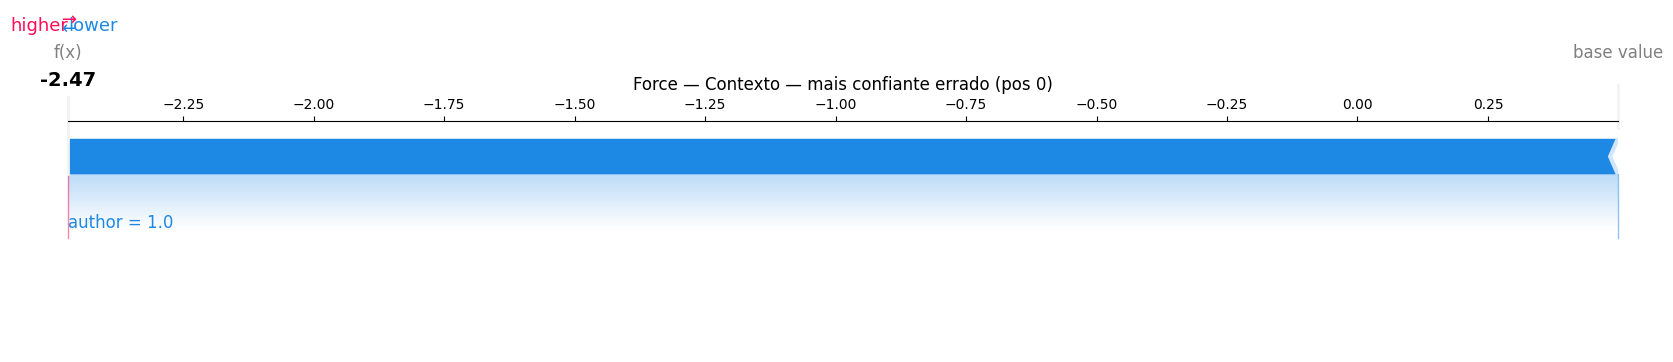

In [81]:
# Garante estado correto — context_model pode ter coef_ com 30 features se o
# mesmo tipo de modelo venceu o cenário Geral (objeto compartilhado no classifiers{})
context_model.fit(X_train_context, y_train_context)
sv_ctx = _shap_values_class1(context_model, X_train_context, X_fr_context)

# ── Beeswarm summary ─────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
shap.summary_plot(sv_ctx, X_fr_context, show=False)
plt.title(f'SHAP Beeswarm — Contexto ({context_model_name}) no FakeRecogna')
plt.savefig('figures/figures_ablacao/shap_context_beeswarm_fakerecogna.pdf', bbox_inches='tight')
plt.show()

# ── Dependence plot: author (hipótese central) ───────────────────────────────
if 'author' in X_fr_context.columns:
    shap.dependence_plot('author', sv_ctx, X_fr_context, show=False)
    plt.title('SHAP dependence — author no FakeRecogna')
    plt.savefig('figures/figures_ablacao/shap_dep_author_fakerecogna.pdf', bbox_inches='tight')
    plt.show()

# ── Force plots ───────────────────────────────────────────────────────────────
proba_ctx  = _proba_class1(context_model, X_fr_context)
pred_ctx   = (proba_ctx >= 0.5).astype(int)
base_ctx   = _proba_class1(context_model, X_train_context).mean()

corretos_ctx = np.where(pred_ctx == y_fr_arr)[0]
errados_ctx  = np.where(pred_ctx != y_fr_arr)[0]

for idx, rotulo in [
    (corretos_ctx[np.argmax(np.abs(proba_ctx[corretos_ctx] - 0.5))] if len(corretos_ctx) else None, 'correto'),
    (errados_ctx[np.argmax(np.abs(proba_ctx[errados_ctx] - 0.5))]   if len(errados_ctx)  else None, 'errado'),
]:
    if idx is None:
        continue
    shap.plots.force(
        base_value=base_ctx,
        shap_values=sv_ctx[idx],
        features=np.round(X_fr_context.iloc[idx].values, 3),
        feature_names=X_fr_context.columns.tolist(),
        matplotlib=True, show=False,
    )
    plt.title(f'Force — Contexto — mais confiante {rotulo} (pos {idx})')
    plt.savefig(f'figures/figures_ablacao/force_context_{rotulo}_fakerecogna.pdf', bbox_inches='tight')
    plt.show()
